In [1]:
# import libraries
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
#load dataset
data = load_breast_cancer()

X = data.data
y = data.target

print(X.shape)
print(y.shape)

(569, 30)
(569,)


In [3]:
#Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [4]:
# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
# Logistic Regression
class LogisticRegression:

    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):

        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0
        self.losses = []

        for _ in range(self.epochs):

            linear_model = np.dot(X, self.weights) + self.bias

            predictions = self.sigmoid(linear_model)

            dw = (1 / n_samples) * np.dot(X.T, (predictions - y))

            db = (1 / n_samples) * np.sum(predictions - y)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            epsilon = 1e-15
            loss = -np.mean(
                y * np.log(predictions + epsilon) +
                (1 - y) * np.log(1 - predictions + epsilon)
            )
            self.losses.append(loss)

    def predict_proba(self, X):

        linear_model = np.dot(X, self.weights) + self.bias

        return self.sigmoid(linear_model)

    def predict(self, X):

        probabilities = self.predict_proba(X)

        return np.where(probabilities >= 0.5, 1, 0)

In [9]:
# Train Model
model = LogisticRegression(
    learning_rate=0.01,
    epochs=5000
)

model.fit(X_train, y_train)

In [10]:
# Metrics
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred)
print(cm)

Accuracy: 0.9824561403508771
[[42  1]
 [ 1 70]]


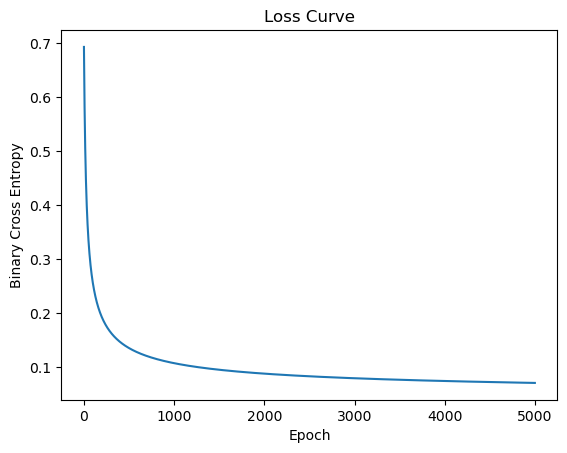

In [11]:
import matplotlib.pyplot as plt

plt.plot(model.losses)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy")
plt.title("Loss Curve")
plt.show()